# Initial Data cleaning

In [80]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [10]:
# Get initial ball data
ball_data = pd.read_csv('data/ball-data.csv')

# Get initial match data
match_data = pd.read_csv('data/match-info.csv')
match_data = match_data.rename(columns={'match_number': 'ID'})
match_data.head()

# Get merged data
merged_data = pd.merge(ball_data, match_data, on='ID', how='left')
merged_data.head()

,ID,Innings,Overs,BallNumber,Batter,Bowler,NonStriker,ExtraType,BatsmanRun,ExtrasRun,...,toss_winner,toss_decision,result,eliminator,winner,player_of_match,venue,city,team1_players,team2_players
0,501208,1,0,1,S Sohal,Z Khan,S Dhawan,NaN,0,0,...,Royal Challengers Bangalore,field,Win,NaN,Deccan Chargers,DW Steyn,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,"S Sohal, S Dhawan, KC Sangakkara, B Chipli, JP...","MA Agarwal, TM Dilshan, Z Khan, V Kohli, AB de..."
1,501208,1,0,2,S Sohal,Z Khan,S Dhawan,NaN,1,0,...,Royal Challengers Bangalore,field,Win,NaN,Deccan Chargers,DW Steyn,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,"S Sohal, S Dhawan, KC Sangakkara, B Chipli, JP...","MA Agarwal, TM Dilshan, Z Khan, V Kohli, AB de..."
2,501208,1,0,3,S Dhawan,Z Khan,S Sohal,NaN,1,0,...,Royal Challengers Bangalore,field,Win,NaN,Deccan Chargers,DW Steyn,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,"S Sohal, S Dhawan, KC Sangakkara, B Chipli, JP...","MA Agarwal, TM Dilshan, Z Khan, V Kohli, AB de..."
3,501208,1,0,4,S Sohal,Z Khan,S Dhawan,NaN,0,0,...,Royal Challengers Bangalore,field,Win,NaN,Deccan Chargers,DW Steyn,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,"S Sohal, S Dhawan, KC Sangakkara, B Chipli, JP...","MA Agarwal, TM Dilshan, Z Khan, V Kohli, AB de..."
4,501208,1,0,5,S Sohal,Z Khan,S Dhawan,wides,0,1,...,Royal Challengers Bangalore,field,Win,NaN,Deccan Chargers,DW Steyn,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,"S Sohal, S Dhawan, KC Sangakkara, B Chipli, JP...","MA Agarwal, TM Dilshan, Z Khan, V Kohli, AB de..."


In [11]:
merged_data.columns

Index(['ID', 'Innings', 'Overs', 'BallNumber', 'Batter', 'Bowler',
       'NonStriker', 'ExtraType', 'BatsmanRun', 'ExtrasRun', 'TotalRun',
       'IsWicketDelivery', 'PlayerOut', 'Kind', 'FieldersInvolved',
       'BattingTeam', 'team1', 'team2', 'match_date', 'toss_winner',
       'toss_decision', 'result', 'eliminator', 'winner', 'player_of_match',
       'venue', 'city', 'team1_players', 'team2_players'],
      dtype='str')

In [44]:
filtered_df = merged_data.drop(columns=['Batter', 'NonStriker', 'toss_winner', 'toss_decision', 'result', 'eliminator', 'venue', 'city', 'team1', 'team2', 'city', 'team1_players', 'team2_players', 'player_of_match', 'winner', 'BattingTeam'])
filtered_df.sort_values(by=['match_date', 'Innings', 'Overs', 'BallNumber'], inplace=True)
filtered_df = filtered_df.reset_index(drop=True)
filtered_df.head(40)

,ID,Innings,Overs,BallNumber,Bowler,ExtraType,BatsmanRun,ExtrasRun,TotalRun,IsWicketDelivery,PlayerOut,Kind,FieldersInvolved,match_date
0,335982,1,0,1,P Kumar,legbyes,0,1,1,0,NaN,NaN,NaN,2008-04-18
1,335982,1,0,2,P Kumar,NaN,0,0,0,0,NaN,NaN,NaN,2008-04-18
2,335982,1,0,3,P Kumar,wides,0,1,1,0,NaN,NaN,NaN,2008-04-18
3,335982,1,0,4,P Kumar,NaN,0,0,0,0,NaN,NaN,NaN,2008-04-18
4,335982,1,0,5,P Kumar,NaN,0,0,0,0,NaN,NaN,NaN,2008-04-18
5,335982,1,0,6,P Kumar,NaN,0,0,0,0,NaN,NaN,NaN,2008-04-18
6,335982,1,0,7,P Kumar,legbyes,0,1,1,0,NaN,NaN,NaN,2008-04-18
7,335982,1,1,1,Z Khan,NaN,0,0,0,0,NaN,NaN,NaN,2008-04-18
8,335982,1,1,2,Z Khan,NaN,4,0,4,0,NaN,NaN,NaN,2008-04-18
9,335982,1,1,3,Z Khan,NaN,4,0,4,0,NaN,NaN,NaN,2008-04-18


## Note

- This data doesn't account for overthrows natively. I'm going to ignore this for now, but in the future, it would be better to scrape commentary data and find overthrows
- This dataset has unique names for unique players, albeit their naming scheme is a little inconsistent

In [28]:
filtered_df['BatsmanRun'].unique()

array([0, 4, 6, 1, 2, 5, 3])

In [53]:
filtered_df['ExtraType'].unique()
# filtered_df[filtered_df['ExtraType'] == 'byes,noballs'].head(20)

<StringArray>
[        'legbyes',               nan,           'wides',            'byes',
         'noballs',         'penalty',   'penalty,wides',    'byes,noballs',
 'legbyes,noballs']
Length: 9, dtype: str

In [40]:
filtered_df['Kind'].unique()

<StringArray>
[                    nan,                'caught',                'bowled',
               'run out',                   'lbw',          'retired hurt',
               'stumped',     'caught and bowled',            'hit wicket',
 'obstructing the field',           'retired out']
Length: 11, dtype: str

# Generating useful stats

For the model, we will use

- Sixes given up
- Wickets (bowled, lbw, c&b, stumped **MAYBE**)
- Wides
- penalty, wides (Only the wides part)
- No Balls (Only 1 per)
- Dot Balls **Maybe**

We will also need to know

- Year
- Economy Rate per year
- Total wickets taken

In [47]:
# Add a new column for year

filtered_df['Year'] = pd.to_datetime(filtered_df['match_date']).dt.year

In [81]:
# Loop through database and create aggregate stats for each bowler each year
rows_list = []

for year in filtered_df['Year'].unique():
    year_data = filtered_df[filtered_df['Year'] == year]
    for bowler in year_data['Bowler'].unique():
        bowler_data = year_data[year_data['Bowler'] == bowler]

        # Legal balls bowled
        total_balls = bowler_data.shape[0]
        total_balls -= bowler_data[bowler_data['ExtraType'].isin(['wides', 'noballs', 'penalty,wides', 'byes,noballs', 'legbyes,noballs', 'penalty'])].shape[0]
        if total_balls < 100:
            continue

        # Overs bowled
        overs_bowled = total_balls / 6

        # Regular runs
        batsman_runs = bowler_data['BatsmanRun'].sum()

        # Wide runs and penalty/wides
        wide_runs = bowler_data[bowler_data['ExtraType'].isin(['wides', 'noballs'])]['ExtrasRun'].sum()
        wide_runs += max(0, bowler_data[bowler_data['ExtraType'].isin(['penalty,wides'])]['ExtrasRun'].sum()-5)

        # No-ball runs and penalty/noballs
        noball_runs = bowler_data[bowler_data['ExtraType'].isin(['noballs'])]['ExtrasRun'].sum()
        noball_runs += len(bowler_data[bowler_data['ExtraType'].isin(['byes,noballs', 'legbyes,noballs'])]) 

        # Total runs given up
        total_runs = batsman_runs + wide_runs + noball_runs

        # Economy rate = total runs / (total balls / 6)
        economy = total_runs / (total_balls / 6) if total_balls > 0 else 0

        # Sixes given up
        sixes = bowler_data[bowler_data['BatsmanRun'] == 6].shape[0]

        # Dot balls bowled
        dot_balls = bowler_data[bowler_data['BatsmanRun'] == 0].shape[0]

        # Total wickets taken
        total_wickets = bowler_data[bowler_data['Kind'].isin(['bowled', 'caught', 'lbw', 'stumped', 'hit wicket', 'caught and bowled'])].shape[0]

        # Fielding Indpendent wickets (bowled, lbw, hit wicker, caught and bowled) [Maybe add stumped later]
        fielding_independent_wickets = bowler_data[bowler_data['Kind'].isin(['bowled', 'caught and bowled', 'lbw', 'hit wicket'])].shape[0]

        rows_list.append({
            'Year': year,
            'Bowler': bowler,
            'Economy': economy,
            'TotalRuns': total_runs,
            'Overs': overs_bowled,
            'TotalBalls': total_balls,
            'TotalWickets': total_wickets,
            'Sixes': sixes,
            'Wides': wide_runs,
            'NoBalls': noball_runs,
            'FI Wickets': fielding_independent_wickets,
            'DotBalls': dot_balls,
        })

bowler_df = pd.DataFrame(rows_list)
bowler_df.sort_values(by=['Economy'], inplace=True)

bowler_df = bowler_df.reset_index(drop=True)
bowler_df.to_csv('data/bowler-stats.csv', index=False)
bowler_df.head(20)


,Year,Bowler,Economy,TotalRuns,Overs,TotalBalls,TotalWickets,Sixes,Wides,NoBalls,FI Wickets,DotBalls
0,2009,M Muralitharan,5.220000,261,50.000000,300,14,6,4,0,7,154
1,2009,JP Duminy,5.314286,93,17.500000,105,4,3,7,0,0,49
2,2020,Rashid Khan,5.335052,345,64.666667,388,20,10,7,0,10,174
3,2012,L Balaji,5.400000,162,30.000000,180,11,3,11,0,3,99
4,2011,R Sharma,5.460000,273,50.000000,300,16,6,2,0,7,134
5,2013,SP Narine,5.468750,350,64.000000,384,22,8,3,0,8,186
6,2012,SP Narine,5.476056,324,59.166667,355,24,10,6,0,8,171
7,2009,A Singh,5.485714,96,17.500000,105,9,2,2,1,3,61
8,2022,SP Narine,5.571429,312,56.000000,336,9,12,7,0,5,148
9,2013,DW Steyn,5.796610,399,68.833333,413,19,7,22,0,9,231


In [78]:
# Side exploration: average economy rate by year
avg_economy_by_year = bowler_df.groupby('Year')['Economy'].mean().reset_index()
avg_economy_by_year.rename(columns={'Economy': 'AverageEconomy'}, inplace=True)
avg_economy_by_year

,Year,AverageEconomy
0,2008,7.985210
1,2009,7.299859
2,2010,7.768280
3,2011,7.540614
4,2012,7.541139
5,2013,7.487542
6,2014,7.997147
7,2015,8.062274
8,2016,8.142694
9,2017,8.198062


# Training the model

In [98]:
recent_year_bowler_df = bowler_df[bowler_df['Year'] >= 2022]

X = recent_year_bowler_df[['Sixes', 'Wides', 'NoBalls', 'FI Wickets', 'DotBalls']].div(recent_year_bowler_df['Overs'], axis=0)
y = recent_year_bowler_df['Economy']

fib_reg = LinearRegression().fit(X, y)

Text(0, 0.5, 'Actual Economy Rate')

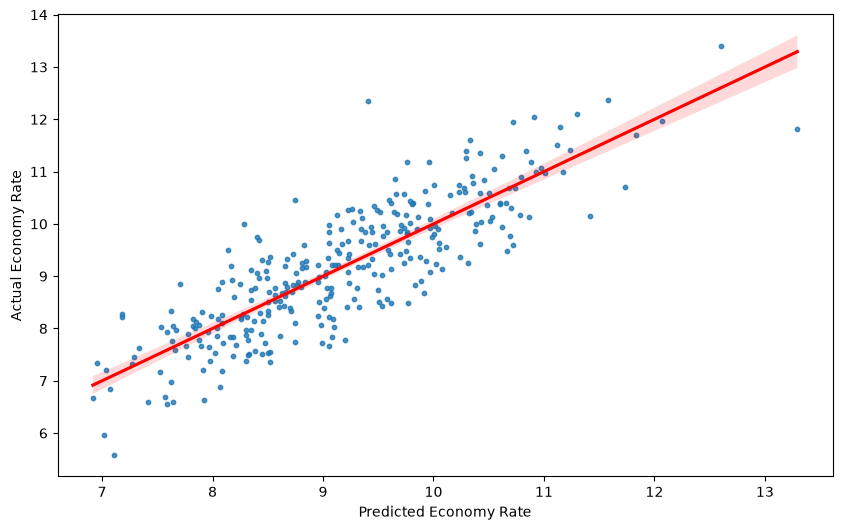

In [99]:
# Display regression
plt.figure(figsize=(10, 6))
sns.regplot(x=fib_reg.predict(X), y=y, scatter_kws={'s':10}, line_kws={'color': 'red'})
plt.xlabel('Predicted Economy Rate')
plt.ylabel('Actual Economy Rate')

In [100]:
# Print regression coefficients
fib_reg.coef_, fib_reg.intercept_ 

# Full training data regression coefficients and intercept:
# 5.1847644 ,  2.87836745,  2.50567393, -2.17970378, -0.82205995]),
#  np.float64(7.957189625273719))

(array([ 5.35025683,  2.92046078,  3.00261996, -2.29261132, -0.69978928]),
 np.float64(7.65369076479482))

# See the meaning

In [101]:
# Store FIB stats for each bowler in the dataframe
fib_coefficients = np.array(fib_reg.coef_)
fib_coefficients = np.insert(fib_coefficients, 0, fib_reg.intercept_)

for index, row in bowler_df.iterrows():
    bowler_df.at[index, 'FIB'] = fib_coefficients[0] + fib_coefficients[1] * (row['Sixes'] / row['Overs']) + \
                                fib_coefficients[2] * (row['Wides'] / row['Overs']) + \
                                fib_coefficients[3] * (row['NoBalls'] / row['Overs']) + \
                                fib_coefficients[4] * (row['FI Wickets'] / row['Overs']) + \
                                fib_coefficients[5] * (row['DotBalls'] / row['Overs'])

bowler_df.sort_values(by=['FIB'], inplace=True)
bowler_df = bowler_df.reset_index(drop=True)
bowler_df.to_csv('data/bowler-stats-with-fib.csv', index=False)
bowler_df.head(20)

,Year,Bowler,Economy,TotalRuns,Overs,TotalBalls,TotalWickets,Sixes,Wides,NoBalls,FI Wickets,DotBalls,FIB
0,2010,AB Dinda,6.561151,152,23.166667,139,9,0,5,0,3,72,5.812236
1,2012,DW Steyn,6.128571,286,46.666667,280,18,2,10,1,10,151,5.817550
2,2009,A Singh,5.485714,96,17.500000,105,9,2,2,1,3,61,5.938209
3,2021,NM Coulter-Nile,6.400000,128,20.000000,120,7,2,1,1,5,54,6.022287
4,2009,M Muralitharan,5.220000,261,50.000000,300,14,6,4,0,7,154,6.053042
5,2013,SP Narine,5.468750,350,64.000000,384,22,8,3,0,8,186,6.139030
6,2011,MM Patel,6.588957,358,54.333333,326,22,5,3,0,2,158,6.187937
7,2013,MM Sharma,6.434211,326,50.666667,304,20,7,7,0,6,169,6.190697
8,2011,R Sharma,5.460000,273,50.000000,300,16,6,2,0,7,134,6.216139
9,2014,B Kumar,6.658307,354,53.166667,319,20,8,8,0,9,167,6.312012


In [107]:
# Store Economy in next year for each bowler in a new dataframe
next_year_economy = []
for index, row in bowler_df.iterrows():
    bowler = row['Bowler']
    year = row['Year']
    next_year_data = bowler_df[(bowler_df['Bowler'] == bowler) & (bowler_df['Year'] == year + 1)]
    if not next_year_data.empty:
        new_row = row.to_dict()
        new_row['next_year_economy'] = next_year_data.iloc[0]['Economy']
        next_year_economy.append(new_row)

next_year_economy_df = pd.DataFrame(next_year_economy).reset_index(drop=True)
next_year_economy_df.head(20)

,Year,Bowler,Economy,TotalRuns,Overs,TotalBalls,TotalWickets,Sixes,Wides,NoBalls,FI Wickets,DotBalls,FIB,next_year_economy
0,2010,AB Dinda,6.561151,152,23.166667,139,9,0,5,0,3,72,5.812236,9.058824
1,2012,DW Steyn,6.128571,286,46.666667,280,18,2,10,1,10,151,5.817550,5.796610
2,2009,M Muralitharan,5.220000,261,50.000000,300,14,6,4,0,7,154,6.053042,6.965753
3,2013,SP Narine,5.468750,350,64.000000,384,22,8,3,0,8,186,6.139030,6.461538
4,2011,MM Patel,6.588957,358,54.333333,326,22,5,3,0,2,158,6.187937,7.950000
5,2013,MM Sharma,6.434211,326,50.666667,304,20,7,7,0,6,169,6.190697,8.396285
6,2011,R Sharma,5.460000,273,50.000000,300,16,6,2,0,7,134,6.216139,8.108108
7,2014,B Kumar,6.658307,354,53.166667,319,20,8,8,0,9,167,6.312012,7.877419
8,2011,SL Malinga,6.000000,378,63.000000,378,28,6,22,3,18,212,6.316186,6.324324
9,2011,Iqbal Abdulla,6.100000,305,50.000000,300,16,6,5,0,5,143,6.357109,6.545455


In [ ]:
# Compare correlation between FIB and next year economy vs current year economy and next year economy
correlation_fib_next_year = next_year_economy_df['FIB'].corr(next_year_economy_df['next_year_economy'])
correlation_current_next_year = next_year_economy_df['Economy'].corr(next_year_economy_df['next_year_economy'])

print(f"Correlation between FIB and next year economy: {correlation_fib_next_year}")
print(f"Correlation between current year economy and next year economy: {correlation_current_next_year}")